In [659]:
import warnings
warnings.filterwarnings('ignore')

try:
    from databook_utils.dandi_utils import dandi_download_open
except:
    !git clone https://github.com/AllenInstitute/openscope_databook.git
    %cd openscope_databook
    %pip install -e .

In [660]:
%pip install numpy pandas scipy matplotlib Pillow
import os
import numpy as np            # various numerical utilities
import pandas as pd
from scipy.stats import poisson
import matplotlib.pyplot as plt
import matplotlib as mpl
from PIL import Image
from math import floor, ceil

In [661]:
import warnings
warnings.filterwarnings('ignore')

try:
    from databook_utils.dandi_utils import dandi_stream_open
except:
    !git clone https://github.com/AllenInstitute/openscope_databook.git
    %cd openscope_databook
    %pip install -e .

In [662]:
%pip install h5py pynwb remfile dandi 
import os

import h5py
import pandas as pd
import remfile

from dandi import dandiapi
from pynwb import NWBHDF5IO

%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [663]:
dandiset_id = "000563"
dandi_filepath = "sub-681446/sub-681446_ses-1290510496_ogen.nwb"
download_loc = "."
dandi_api_key = None

In [664]:
my_dandiset = dandiapi.DandiAPIClient(token=dandi_api_key).get_dandiset(dandiset_id)
print(f"Got dandiset {my_dandiset}")

Got dandiset DANDI:000563/0.250311.2145


In [665]:
nwb_type = "ephys" # or, "ophys"

In [666]:
# get experimental information from within ecephys file
# getattr is used because not all nwb files have all properties. If not handled like this, errors will arise
def get_ephys_nwb_info(nwb):
        session_time = getattr(nwb, "session_start_time", None)

        subject = getattr(nwb, "subject", None)
        specimen_name = getattr(subject, "specimen_name", None)
        age = getattr(subject, "age_in_days", None)
        sex = getattr(subject, "sex", None)
        genotype = getattr(subject, "genotype", None)

        probes = set(getattr(nwb, "devices", {}).keys())
        units = getattr(nwb, "units", [])
        n_units = len(units) if hasattr(units, '__len__') else 0        
        
        intervals = getattr(nwb, "intervals", {})
        stim_types = set(intervals.keys())
        stim_tables = [intervals[table_name] for table_name in intervals]
        # gets highest value among final "stop times" of all stim tables in intervals
        session_end = max([table.stop_time[-1] for table in stim_tables if len(table) > 1])

        return [session_time, specimen_name, sex, age, genotype, probes, stim_types, n_units, session_end]

In [667]:
nwb_table = []
# skip files that aren't main session files
files = [asset for asset in my_dandiset.get_assets() if "probe" not in asset.path]
# swap this with line above for one of our ophys dandisets
# files = [asset for asset in my_dandiset.get_assets() if "raw" not in asset.path]
n_files = len(files)
print(f"{n_files} files retrieved")

extract_nwb_info = get_ephys_nwb_info if nwb_type == "ephys" else get_ophys_nwb_info

for i, file in enumerate(files):
    print(f"Examining file {i+1}/{n_files}: {file.identifier}")    
    # get basic file metadata
    row = [file.identifier, file.size, file.path]
    
    base_url = file.client.session.head(file.base_download_url)
    file_url = base_url.headers["Location"]

    # open and read nwb file with streaming
    rem_file = remfile.File(file_url)
    h5py_file = h5py.File(rem_file, "r")
    io = NWBHDF5IO(file=h5py_file, mode="r", load_namespaces=True)
    nwb = io.read()

    # extract experimental info from within file
    row += extract_nwb_info(nwb)
    nwb_table.append(row)
    del nwb

    # don't run full loop if running in test environment
    if os.environ.get("TESTING", False):
        break

14 files retrieved
Examining file 1/14: c3bbf094-904e-43b7-83d5-be5a8bf3826f
Examining file 2/14: ad5f1431-2119-4e85-b98e-0a89d5c6fd08
Examining file 3/14: 26c15f00-af2c-4cc3-97a2-ab32dbe998ae
Examining file 4/14: 9f6591b5-22b5-4a23-8009-d9cfba9fe525
Examining file 5/14: cbc9402d-64ff-4a8f-a688-add16d7b984c
Examining file 6/14: ae100c59-59ce-4f46-b4be-0d68ea357372
Examining file 7/14: e367b37d-c854-45ba-bdae-602df4614dea
Examining file 8/14: 0e172dc4-eeb4-408d-946f-c80d83cce34a
Examining file 9/14: 518fffd6-6ad2-4021-89eb-c0bb1767d541
Examining file 10/14: 96786f67-a6ac-44dc-ba58-61317082fff3
Examining file 11/14: 74d2c6b9-8bbf-4ff1-b2a2-b91d401c12bb
Examining file 12/14: 2f2ac304-83a3-4352-8612-5f34b68062a0
Examining file 13/14: fb92563d-0e56-4c61-aa86-5645a637fa2d
Examining file 14/14: 9bdb7302-dce6-4da7-b8b3-10b4bf9c998c


In [668]:
# convert table to pandas dataframe
if nwb_type == "ephys":
    dandiset_files = pd.DataFrame(nwb_table, columns=("identifier", "size", "path", "session_time", "sub_name", "sub_sex", "sub_age", "sub_genotype", "probes", "stim types", "#_units", "session_length"))
else:
    dandiset_files = pd.DataFrame(nwb_table, columns=("identifier", "size", "path", "session_time", "sub_name", "session_id", "experiment_id", "container_id", "group", "group_count", "imaging_depth", "location", "fov_height", "fov_width", "specimen_name", "sub_sex", "sub_age", "sub_genotype", "stim_types", "#_rois", "session_end"))
dandiset_files

,identifier,size,path,session_time,sub_name,sub_sex,sub_age,sub_genotype,probes,stim types,#_units,session_length
0,c3bbf094-904e-43b7-83d5-be5a8bf3826f,2828829044,sub-699241/sub-699241_ses-1318772854_ogen.nwb,2023-12-19 00:00:00-08:00,699241,M,124.0,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{OptogeneticStimulusDevice, probeF, probeD, pr...","{RepeatFFF_presentations, receptive_field_bloc...",2299,7251.236727
1,ad5f1431-2119-4e85-b98e-0a89d5c6fd08,2992502541,sub-699846/sub-699846_ses-1314466742_ogen.nwb,2023-11-30 00:00:00-08:00,699846,M,100.0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{OptogeneticStimulusDevice, probeF, probeD, pr...","{RepeatFFF_presentations, receptive_field_bloc...",2771,7248.796817
2,26c15f00-af2c-4cc3-97a2-ab32dbe998ae,4721689639,sub-698259/sub-698259_ses-1314229564_ogen.nwb,2023-11-29 00:00:00-08:00,698259,M,111.0,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{OptogeneticStimulusDevice, probeF, probeD, pr...","{RepeatFFF_presentations, receptive_field_bloc...",2744,12104.177757
3,9f6591b5-22b5-4a23-8009-d9cfba9fe525,3058306362,sub-692990/sub-692990_ses-1310924284_ogen.nwb,2023-11-14 00:00:00-08:00,692990,F,129.0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{OptogeneticStimulusDevice, probeF, probeD, pr...","{RepeatFFF_presentations, receptive_field_bloc...",3338,7248.085747
4,cbc9402d-64ff-4a8f-a688-add16d7b984c,2973901434,sub-697302/sub-697302_ses-1309845146_ogen.nwb,2023-11-09 00:00:00-08:00,697302,F,97.0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{OptogeneticStimulusDevice, probeF, probeD, pr...","{RepeatFFF_presentations, receptive_field_bloc...",2824,7248.555437
5,ae100c59-59ce-4f46-b4be-0d68ea357372,3077972048,sub-697303/sub-697303_ses-1309536438_ogen.nwb,2023-11-08 00:00:00-08:00,697303,F,96.0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{OptogeneticStimulusDevice, probeF, probeD, pr...","{RepeatFFF_presentations, receptive_field_bloc...",3465,7254.287277
6,e367b37d-c854-45ba-bdae-602df4614dea,3157021325,sub-692360/sub-692360_ses-1301730660_ogen.nwb,2023-10-05 00:00:00-07:00,692360,M,94.0,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{OptogeneticStimulusDevice, probeF, probeD, pr...","{RepeatFFF_presentations, receptive_field_bloc...",2844,7250.575147
7,0e172dc4-eeb4-408d-946f-c80d83cce34a,2739385785,sub-692991/sub-692991_ses-1308221984_ogen.nwb,2023-11-02 00:00:00-07:00,692991,F,117.0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{OptogeneticStimulusDevice, probeF, probeD, pr...","{RepeatFFF_presentations, receptive_field_bloc...",2529,7248.935487
8,518fffd6-6ad2-4021-89eb-c0bb1767d541,2978882451,sub-692984/sub-692984_ses-1303229472_ogen.nwb,2023-10-12 00:00:00-07:00,692984,M,96.0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{OptogeneticStimulusDevice, probeF, probeD, pr...","{RepeatFFF_presentations, receptive_field_bloc...",2892,7249.644247
9,96786f67-a6ac-44dc-ba58-61317082fff3,2555712145,sub-685263/sub-685263_ses-1292234897_ogen.nwb,2023-08-23 00:00:00-07:00,685263,M,95.0,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{OptogeneticStimulusDevice, probeF, probeD, pr...","{RepeatFFF_presentations, receptive_field_bloc...",2791,7248.094377


In [669]:
if nwb_type == "ephys":
    m_count = len(dandiset_files["sub_sex"][dandiset_files["sub_sex"] == "M"])
    f_count = len(dandiset_files["sub_sex"][dandiset_files["sub_sex"] == "F"])
    sst_count = len(dandiset_files[dandiset_files["sub_genotype"].str.count("Sst") >= 1])
    pval_count = len(dandiset_files[dandiset_files["sub_genotype"].str.count("Pval") >= 1])
    wt_count = len(dandiset_files[dandiset_files["sub_genotype"].str.count("wt/wt") >= 1])
    print("Dandiset Overview:")
    print(len(dandiset_files), "dandiset_files")
    print(len(set(dandiset_files["sub_name"])), "subjects", m_count, "males,", f_count, "females")
    print(sst_count, "sst,", pval_count, "pval,", wt_count, "wt")
else:
    n_sessions = len(dandiset_files["session_id"].value_counts())
    subjects_info = dandiset_files.groupby(["sub_name", "sub_sex"]).size().reset_index().to_dict()
    m_count = len([sex for sex in subjects_info["sub_sex"].values() if sex == "M"])
    f_count = len([sex for sex in subjects_info["sub_sex"].values() if sex == "F"])
    print("Dandiset Overview:")
    print(len(dandiset_files), "dandiset_files")
    print(len(subjects_info["sub_name"]), "subjects", m_count, "males", f_count,"females")

Dandiset Overview:
14 dandiset_files
14 subjects 9 males, 5 females
8 sst, 6 pval, 0 wt


In [670]:
# output all session metadata to local CSV file
dandiset_files.to_csv("dandiset_files.csv")

In [671]:
selected_files = dandiset_files[dandiset_files["size"] <= 2_628_829_044]

selected_files

,identifier,size,path,session_time,sub_name,sub_sex,sub_age,sub_genotype,probes,stim types,#_units,session_length
9,96786f67-a6ac-44dc-ba58-61317082fff3,2555712145,sub-685263/sub-685263_ses-1292234897_ogen.nwb,2023-08-23 00:00:00-07:00,685263,M,95.0,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{OptogeneticStimulusDevice, probeF, probeD, pr...","{RepeatFFF_presentations, receptive_field_bloc...",2791,7248.094377
11,2f2ac304-83a3-4352-8612-5f34b68062a0,2504326547,sub-681446/sub-681446_ses-1290510496_ogen.nwb,2023-08-16 00:00:00-07:00,681446,M,112.0,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{OptogeneticStimulusDevice, probeF, probeD, pr...","{RepeatFFF_presentations, receptive_field_bloc...",2572,7249.424087


In [672]:
download_loc = "."

In [673]:
selected_paths = set(selected_files.path)
selected_paths

{'sub-681446/sub-681446_ses-1290510496_ogen.nwb',
 'sub-685263/sub-685263_ses-1292234897_ogen.nwb'}

In [674]:
#for dandi_filepath in selected_paths:
#    filename = dandi_filepath.split("/")[-1]
#    file = my_dandiset.get_asset_by_path(dandi_filepath)
#    file.download(f"{download_loc}/{filename}")
#    print(f"Downloaded file to {download_loc}/{filename}")

In [675]:
session_files = pd.read_csv(r"C:\Users\gamei\Downloads\NeurSysProject\openscope_databook\dandiset_files.csv")
session_files

m_count = len(session_files["sub_sex"][session_files["sub_sex"] == "M"])
f_count = len(session_files["sub_sex"][session_files["sub_sex"] == "F"])
sst_count = len(session_files[session_files["sub_genotype"].str.count("Sst") >= 1])
pval_count = len(session_files[session_files["sub_genotype"].str.count("Pval") >= 1])
wt_count = len(session_files[session_files["sub_genotype"].str.count("wt/wt") >= 1])

print("Dandiset Overview:")
print(len(session_files), "files")
print(len(set(session_files["sub_name"])), "subjects", m_count, "males,", f_count, "females")
print(sst_count, "sst,", pval_count, "pval,", wt_count, "wt")

Dandiset Overview:
14 files
14 subjects 9 males, 5 females
8 sst, 6 pval, 0 wt


In [676]:
# This can sometimes take a while depending on the size of the file
io = dandi_download_open(dandiset_id, dandi_filepath, download_loc, dandi_api_key=dandi_api_key)
nwb = io.read()

File already exists
Opening file


In [677]:
try:
    from databook_utils.dandi_utils import dandi_download_open
except:
    !git clone https://github.com/AllenInstitute/openscope_databook.git
    %cd openscope_databook
    %pip install -e .

In [678]:
%pip install ccfwidget itkwidgets
import numpy as np

from ccfwidget import CCFWidget

# required because CCFwidgets is not using latest version of collections.abc
import collections
import collections.abc
collections.Sequence = collections.abc.Sequence

Note: you may need to restart the kernel to use updated packages.


In [679]:
dandiset_id = "000563"
dandi_filepath = "sub-681446/sub-681446_ses-1290510496_ogen.nwb"
download_loc = "."

In [680]:
# This can sometimes take a while depending on the size of the file
io = dandi_download_open(dandiset_id, dandi_filepath, download_loc)
nwb = io.read()

File already exists
Opening file


In [681]:
### read the x,y,z ccf coordinates and generate points
xs = nwb.electrodes.x
ys = nwb.electrodes.y
zs = nwb.electrodes.z
n = min(len(xs), len(ys), len(zs))
points = np.array([[xs[i], ys[i], zs[i]] for i in range(n)])

In [682]:
# each point has 3 coordinates associated with it
print(points.shape)

(2304, 3)


In [683]:
# the 'markers' parameter will expect an iterable where each point is represented as [x,y,z]ccf = CCFWidget(markers=[points])

In [684]:
# Helper function to find the brain location of each unit
def getUnitsLocation(nwb):
    """
   
    INPUTS:
      nwb      an nwb object
    OUTPUTS:
      unit_locations  List of the assigned brain locations of all units in the units table
    """
    units=nwb.units
    units_peak_channel_id = list(units.peak_channel_id)
    n_units=len(units_peak_channel_id)
    electrodes = nwb.electrodes  
    channelLocations=list(electrodes.location) # anatomic locations of each channel
    channelIDs =list(electrodes.id)  # the id for that channel
    unit_locations=np.zeros((n_units,)).astype(str)
    for i in range(n_units):
        #find the brain region closest to the channel which has the peak value for that unit
        unit_locations[i]=channelLocations[channelIDs.index(units_peak_channel_id[i])] 
    return unit_locations

In [685]:
# Load the unit information needed for the anlaysis
units = nwb.units          # extract spike times from the Units Data table 
units_spike_times = units["spike_times"] # pull out the `spike_times` attribute to be used later
n_units = len(units_spike_times)
print('Number of units: ',n_units)

# example of unit properties one might use to filter the units
units_quality = list(units["quality"]) # quality metric of each unit - list of strings
units_isiviol = list(units["isi_violations"]) # isi violation metric or each unit - list of floats

# make a list with indexes of selected units
goodUnits=[]
for i in range(len(units_quality)):
    if units_quality[i]=='good' and units_isiviol[i]<1:
        goodUnits.append(i)
        
print('of which ', len(goodUnits), 'qualify for inclusion')

#retrieve the anatomical locations assigned to the units
units_location = getUnitsLocation(nwb)
print('The selected units were found in: ')
np.unique(units_location[goodUnits])

Number of units:  2572
of which  1511 qualify for inclusion
The selected units were found in: 


array(['APN', 'CA1', 'CA2', 'CA3', 'DG-mo', 'DG-po', 'DG-sg', 'HPF',
       'LGd-co', 'LGd-ip', 'LGd-sh', 'LP', 'MB', 'MRN', 'POST', 'SCig',
       'SSp-bfd4', 'SSp-bfd5', 'SSp-bfd6a', 'TH', 'VISal1', 'VISal2/3',
       'VISal4', 'VISal5', 'VISal6a', 'VISam2/3', 'VISam4', 'VISam5',
       'VISam6a', 'VISam6b', 'VISl4', 'VISl5', 'VISl6a', 'VISl6b',
       'VISp2/3', 'VISp4', 'VISp5', 'VISp6a', 'VISpm2/3', 'VISpm4',
       'VISpm5', 'VISpm6a', 'root'], dtype='<U32')

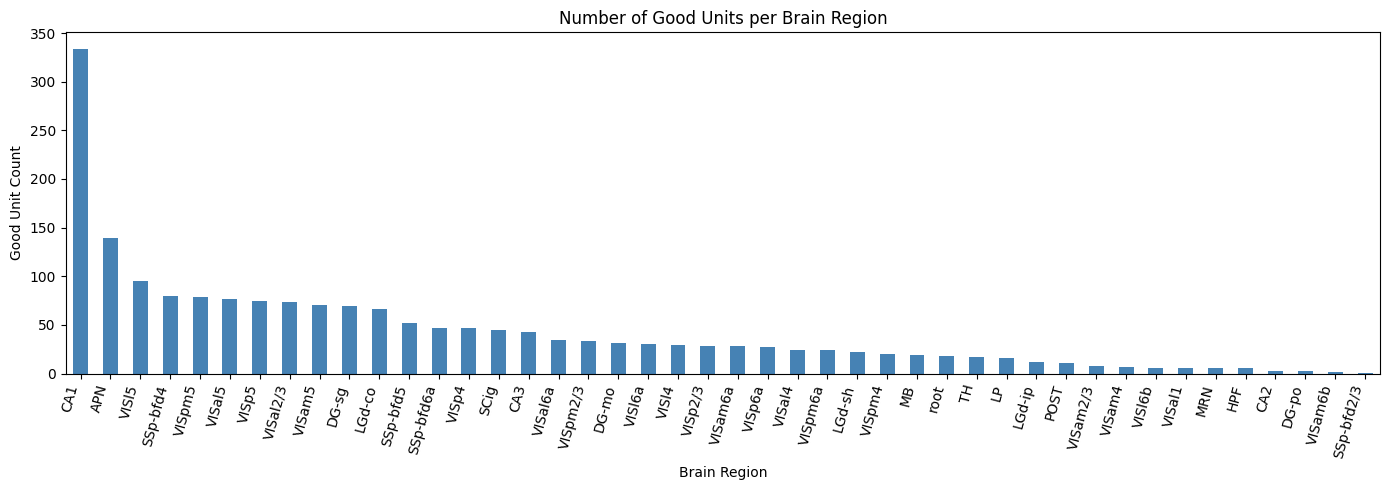

,sub_genotype,n_sessions,total_units,mean_units_per_session
0,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,8,23723,2965.375
1,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,6,15657,2609.500


In [720]:
# Bar chart: number of good units per brain region
good_mask = np.array(units_quality) == "good"
good_units_by_region = (
    pd.Series(units_location[good_mask], name="brain_region")
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 5))
good_units_by_region.plot(kind="bar", color="steelblue")
plt.title("Number of Good Units per Brain Region")
plt.xlabel("Brain Region")
plt.ylabel("Good Unit Count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

# Table: number of units per genotype
source_df = session_files if "session_files" in globals() else dandiset_files
units_per_genotype = (
    source_df.groupby("sub_genotype", dropna=False)["#_units"]
    .agg(n_sessions="count", total_units="sum", mean_units_per_session="mean")
    .sort_values("total_units", ascending=False)
    .reset_index()
)

units_per_genotype

In [686]:
# Find out what stimulus conditions were used in the experiment
# See bottom of this notebook for more about the timeline of the entire experiment
StimulusTypes=list(nwb.intervals.keys())
StimulusTypes

['RepeatFFF_presentations',
 'UniqueFFF_presentations',
 'invalid_times',
 'receptive_field_block_presentations',
 'static_block_presentations']

In [687]:
# The full field flicker stimulus was sufficient to observe a barcode in all units that had barcodes,
# and is the easiest to interpret because all neurons had the identical stimulus in their receptive fields 
stimTypeToExtract='RepeatFFF_presentations'
# Information about the stimulus
stim_table = nwb.intervals[stimTypeToExtract]    
stim_table

,start_time,stop_time,stimulus_name,stimulus_block,index_repeat,contrast,mask,opacity,orientation,phase,spatial_frequency,size,units,stimulus_index,color,tags,timeseries
id,,,,,,,,,,,,,,,,,
0,163.46116,163.47784,RepeatFFF,1.0,0.0,1.0,None,1.0,0.0,"[0.0, 0.0]","[0.0, 0.0]","[250.0, 250.0]",deg,1.0,1.0,[stimulus_time_interval],"[(7200, 1, timestamps pynwb.base.TimeSeries at 0x2720993905200\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (405120,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (405120,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"
1,163.47784,163.49453,RepeatFFF,1.0,0.0,1.0,None,1.0,0.0,"[0.0, 0.0]","[0.0, 0.0]","[250.0, 250.0]",deg,1.0,1.0,[stimulus_time_interval],"[(7201, 1, timestamps pynwb.base.TimeSeries at 0x2720993905200\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (405120,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (405120,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"
2,163.49453,163.51118,RepeatFFF,1.0,0.0,1.0,None,1.0,0.0,"[0.0, 0.0]","[0.0, 0.0]","[250.0, 250.0]",deg,1.0,-1.0,[stimulus_time_interval],"[(7202, 1, timestamps pynwb.base.TimeSeries at 0x2720993905200\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (405120,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (405120,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"
3,163.51118,163.52780,RepeatFFF,1.0,0.0,1.0,None,1.0,0.0,"[0.0, 0.0]","[0.0, 0.0]","[250.0, 250.0]",deg,1.0,-1.0,[stimulus_time_interval],"[(7203, 1, timestamps pynwb.base.TimeSeries at 0x2720993905200\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (405120,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (405120,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"


In [688]:
# pull out some stimulus details we will need for our analysis
StimIndexList=np.unique(np.array((stim_table["stimulus_index"])) )  # array of stimulus conditions 
IndexRepeatList=np.unique(np.array((stim_table["index_repeat"]))) # array of repeat numbers within the block 
StimNameList=set(stim_table["stimulus_name"])
nPresentations=len(StimIndexList); # determine number of instances from the data
# determine nRepeats from the data
nRepeats=len(IndexRepeatList)
print(stimTypeToExtract,' was repeated ',nRepeats,' times')

RepeatFFF_presentations  was repeated  90  times


In [689]:
# Find the start times of the repeated stimulus
# cast the index_repeat and stim_index columns from  hdmf.common.table.VectorData into arrays
index_repeat=np.array(stim_table["index_repeat"])  
stim_index=np.array(stim_table["stimulus_index"])
# note that the repeats are not necessarily back to back so the duration is determined by 
# the end time of the same repeat, not the start time of the next repeat
stim_times=np.zeros(nRepeats*nPresentations)
endtime=np.zeros(nRepeats*nPresentations)
for k in range(nPresentations): #loop over presentations of this stimulus
    mask1=stim_index==StimIndexList[k] #true for all elements in this presentation
    for j in range(nRepeats):   #loop over repeats within the presentation
        mask2=index_repeat==j #true for all elements with this repeat number
        ind1=np.where(np.logical_and(mask1,mask2))[0][0] # index of first element meeting conditions
        stim_times[k*nRepeats+j]= stim_table["start_time"][ind1]

        ind2=np.where(np.logical_and(mask1,mask2))[0][-1]  # index of last element meeting conditions
        endtime[k*nRepeats+j]= stim_table["stop_time"][ind2]

# the actual duration of each repeat is given by end_time-start_time
# average these to get the nominal duration for all trials, for further analysis
eachduration=endtime-stim_times # the values should be close to identical (check this)
trial_duration=np.mean(eachduration) # then set the "duration" variable to the mean duration 
trial_duration=np.round(trial_duration*1000)/1000  #truncated to three significant digits

totalStimTime=trial_duration*nRepeats # time in seconds total over all repeats

In [690]:
#  makeAlignedEvents:  a helper function that extracts and aligns spike times for one unit
def makeAlignedEvents(spike_times,stim_times,duration:float):
    """
    INPUTS:
    spike_times     array of spike times of a single unit, in seconds
    stim_times      array of start times of a repeated stimulus, in seconds
    duration        duration of the repeated stimulus, in seconds
    
    OUTPUTS:
    events          1D array whose elements are all times when a spike is seen in a repeat relative to the start of repeat
  
    """
    nRepeats=len(stim_times) #number of stim_time entries would give us the number of repeats for that stimulus
    events=np.zeros((nRepeats,)).tolist()
    
    for stim_idx, stim_time in enumerate(stim_times): 
        first_spike_in_range, last_spike_in_range = np.searchsorted(spike_times, [stim_time, stim_time+duration])
        spike_times_in_range = np.array(spike_times[first_spike_in_range:last_spike_in_range])  
        spike_times_in_range=spike_times_in_range-stim_time #set trial start as time 0 
        events[stim_idx]=spike_times_in_range.tolist()

    return events

In [691]:
# Choose example units to illustrate the barcode analysis methods
# These examples were chosen to illustrate two different barcodes and a neuron without a barcode
# in the sections below
example_indices = goodUnits

# Extract the aligned spike times of the example neurons
rasters=[] # the aligned spike times
FR =[]     # firing rate  
for i in range(len(example_indices)):
    rasters.append( makeAlignedEvents(units_spike_times[example_indices[i]],stim_times,trial_duration) )
    # count spikes in all the repeats to estimate the firing rate
    nspk=0 
    for j in range(nRepeats):
        nspk += len(rasters[i][j])
    FR.append(nspk/totalStimTime) 
    # print summary information about the examples
    print('example', i+1, 'is unit',example_indices[i],', recorded from ', units_location[example_indices[i]], ', FR=',np.round(FR[i],1),' spk/sec')

example 1 is unit 0 , recorded from  APN , FR= 0.6  spk/sec
example 2 is unit 1 , recorded from  APN , FR= 46.0  spk/sec
example 3 is unit 2 , recorded from  APN , FR= 0.4  spk/sec
example 4 is unit 3 , recorded from  APN , FR= 8.3  spk/sec
example 5 is unit 4 , recorded from  APN , FR= 10.0  spk/sec
example 6 is unit 5 , recorded from  APN , FR= 12.2  spk/sec
example 7 is unit 6 , recorded from  APN , FR= 17.8  spk/sec
example 8 is unit 7 , recorded from  APN , FR= 15.5  spk/sec
example 9 is unit 8 , recorded from  APN , FR= 0.3  spk/sec
example 10 is unit 9 , recorded from  APN , FR= 0.8  spk/sec
example 11 is unit 10 , recorded from  APN , FR= 41.2  spk/sec
example 12 is unit 11 , recorded from  APN , FR= 0.6  spk/sec
example 13 is unit 13 , recorded from  APN , FR= 26.0  spk/sec
example 14 is unit 15 , recorded from  APN , FR= 1.2  spk/sec
example 15 is unit 16 , recorded from  APN , FR= 9.5  spk/sec
example 16 is unit 17 , recorded from  APN , FR= 5.7  spk/sec
example 17 is unit 1

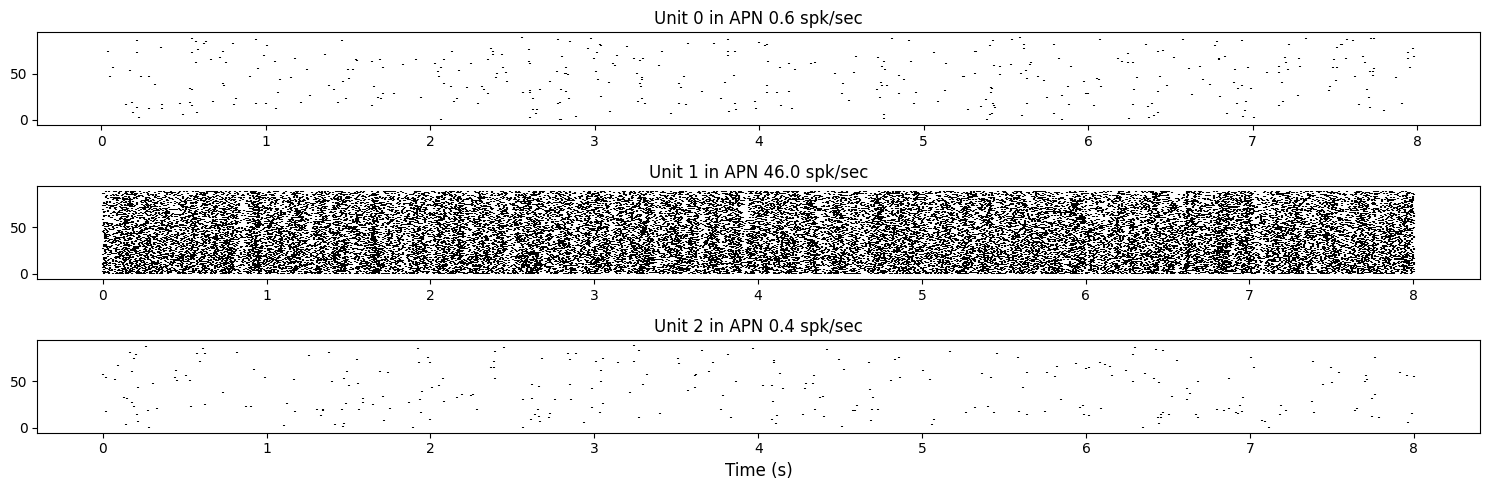

In [692]:
#show rasters for three example cells
fig, axes = plt.subplots(3, 1, figsize=(15, 5))  # 1 row, 3 columns
for i in range(3):
    axes[i].eventplot(rasters[i], colors='black')
    title = "Unit %d in %s %.1f spk/sec" % (example_indices[i], units_location[example_indices[i]],FR[i])
    axes[i].set_title(title)

plt.xlabel("Time (s)", fontsize=12) 
plt.tight_layout()
plt.show()

In [693]:
# compute_psth: helper function to compute PSTH by assigning spike times to time bins
def compute_psth(spike_trains, total_duration, bin_duration):
    n_bins = int(total_duration / bin_duration)
    psth = np.zeros(n_bins, dtype=float)
    for train in spike_trains:
        binned_spikes = np.floor(np.array(train) / bin_duration).astype(int)
        valid_bins = binned_spikes[binned_spikes < n_bins]
        psth[valid_bins] += 1
    psth /= len(spike_trains)
    return psth 

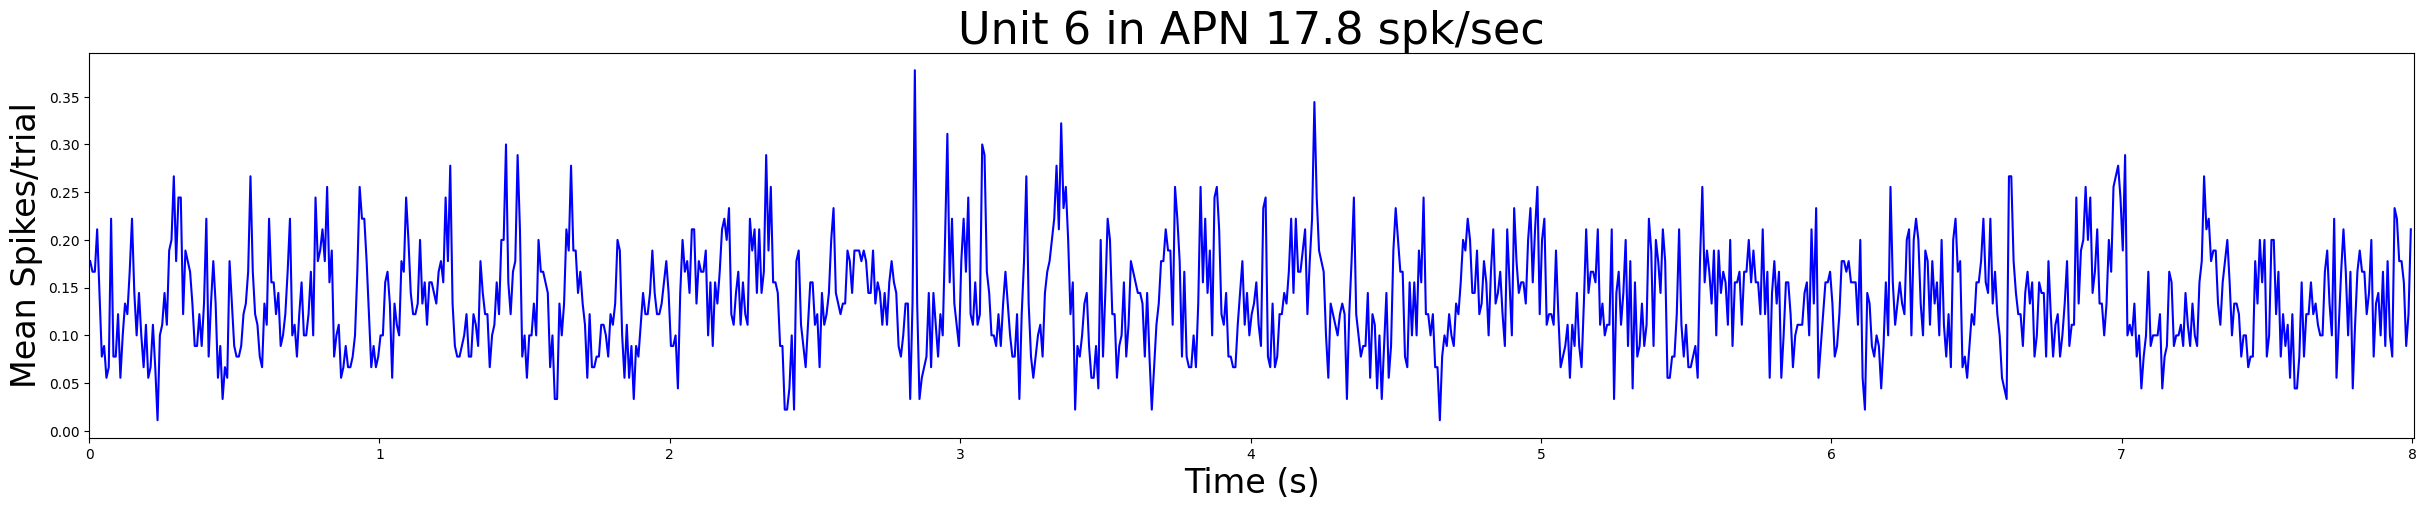

In [694]:
# Plot the psth of one of the example neurons 
example=6  # first example neuron
bin_duration = 0.008 # Time bin to use in seconds 
psth1=compute_psth(rasters[example], trial_duration, bin_duration)
n_bins = len(psth1)
bin_midpoints = (np.arange(n_bins) + 0.5) * bin_duration
fig, ax = plt.subplots(figsize=(30, 5))
plt.plot(bin_midpoints, psth1, color='blue')
plt.xlabel('Time (s)',fontsize=24)
plt.ylabel('Mean Spikes/trial',fontsize=24)
title = "Unit %d in %s %.1f spk/sec" % (example_indices[example], units_location[example_indices[example]],FR[example])
plt.title(title,fontsize=32)
plt.xlim([0,trial_duration])
plt.show()

In [695]:
# getSpikeCountThreshold: helper function to determine the number of spikes in psth bin expected by chance
def getSpikeCountThreshold(rate, M, N, alpha, doplot=False):
    """
    Returns criterion spike-count thresholds (high and low) for detecting
    significantly above- or below-chance spike counts in any one time bin
    of a raster, under a Poisson null hypothesis.

    Parameters
    ----------
    rate : float
        Mean spikes per bin in the data raster overall
    M : int
        Number of trials in the data raster
    N : int
        Number of time bins in the data raster
    alpha : float
        Acceptable fraction of false positives (e.g., 0.05)
    doplot : bool, optional
        If True, plot the PDF and thresholds (default False)

    Returns
    -------
    highThresh : int
        Minimum spike count significantly above chance (Bonferroni-corrected)
    lowThresh : int
        Maximum spike count significantly below chance, or -1 if none
    """
    # Bonferroni correction for multiple comparisons
    adj_alpha = alpha / N
    
    # Find low threshold
    Clow = 0
    while poisson.pmf(Clow, rate * M) < adj_alpha:
        Clow += 1
    lowThresh = Clow - 1  # If Clow never increments, this becomes -1

    # Find high threshold, starting from Clow
    Chigh = Clow
    while poisson.pmf(Chigh, rate * M) > adj_alpha:
        Chigh += 1
    highThresh = Chigh

    # Optional plotting
    if doplot:
        C = np.arange(0, Chigh + 1)
        P = poisson.pmf(C, rate * M)
        plt.figure()
        plt.semilogy(C, P, 'o-')
        plt.xlabel(f'Spike count over M={M} trials')
        plt.ylabel('Probability on Poisson Null')
        plt.title(f'For Mean {rate:.3f} spikes/bin, N={N} timebins')
        plt.axhline(y=adj_alpha, color='r', linestyle='-')
        plt.text(Chigh, adj_alpha, f' α={alpha:.2f}', color='r')
        plt.text(Chigh / 2, 3 * adj_alpha, 'nonsignificant',
                 ha='center', color='r')
        plt.text(Chigh / 2, adj_alpha / 3, 'significant',
                 ha='center', color='r')
        plt.xticks() # to be coded: force xticks to be integers
        plt.show()

    return highThresh, lowThresh

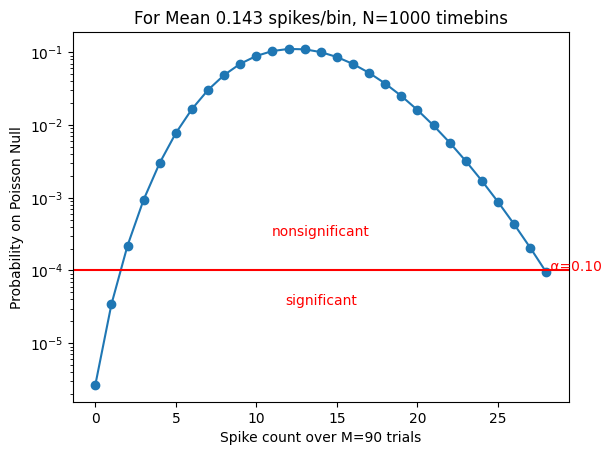

Time bins with >= 28  spikes over the  90  repeats qualify as bars


In [696]:
# Compute the threshold criterion for a sample neuron (same example selected above)
alpha=0.1 # a significance criterion
rate=FR[example]*bin_duration # rate in spikes per time bin
highThresh, lowThresh = getSpikeCountThreshold(rate, nRepeats, n_bins, alpha, True)
print('Time bins with >=',highThresh,' spikes over the ',nRepeats,' repeats qualify as bars')

In [697]:
# find_bars: helper function to return the bar code of a spike raster
def find_bars(spike_train, trial_duration, bin_duration,min_spikes):
    '''
    Identifies the times of PSTH peaks as bars of a barcode by a simple algorithm:
    All consecutive time bins above set threshold are considered to be part of the same bar, 
     the mean of those bin midpoints is considered to be the bar time
    INPUTS
        spike_train     raster for a repeated stimulus as a list of aligned spike time lists
        trial_duration  the duration of the repeated stimulus 
        bin_duration    bin size to use for the psth
        min_spikes      minimum integer number of spikes in a bin (summed over repeats)
                        for inclusion in peak identification
    OUTPUTS
        bars            times of the barcode bars in s relative to stimulus onset
        psth            the psth curve as mean number of spikes in bin per trial
        bin_midpoints   time axis for the psth
    '''
    nRepeats=len(spike_train) # number of repeats in raster
    psth=compute_psth(spike_train, trial_duration, bin_duration) # mean number of spikes in bin per trial
    significant_array = psth*nRepeats >=  min_spikes # convert psth to integer spike count to compare to minspikes
    significant_indices = np.where(significant_array)[0] #indexes to qualifying time bins
    n_bins = len(psth) 
    bin_midpoints = (np.arange(n_bins) + 0.5) * bin_duration

    # Consecutive qualifying time bins are considered part of the same "Bar"
    # The time of that bar is considered to be the mean of those bin centers
    bars = []
    current_group = []
    for idx in significant_indices:
        if not current_group or idx == current_group[-1] + 1:
            current_group.append(idx)
        else:
            bars.append(np.mean(bin_midpoints[current_group]))
            current_group = [idx]
    if current_group:
        bars.append(np.mean(bin_midpoints[current_group]))

    return bars,psth, bin_midpoints

In [698]:
# plotPSTHbarcode: helper function to plot PSTH and illustrate how bar times are derived
def plotPSTHbarcode(psth, bin_midpoints, threshold, bars, xlim =[0, 1],title='PSTH and Barcode'):
    '''
    Visualization of barcode extraction from psth
    Plots the psth, threshold, and identified peak midpoints
    INPUTS
        psth           psth expressed as mean spikes in bin over repeats
        bin_midpoints  time axis for the psth
        threshold      threshold expressed as mean spikes in bin over repeats
        bars           times of identified bars
        xlim           optional axis limits
        title          optional figure title
    '''
    fs=24 # font size
    fig, ax = plt.subplots(figsize=(30, 5))
    plt.plot(bin_midpoints, psth,  label='PSTH',color='blue')
    plt.xlabel('Time (s)',fontsize=fs)
    plt.ylabel('Mean Spike Count',fontsize=fs)
    plt.title(title,fontsize=1.5*fs)
    plt.xlim(xlim)

    # Plot threshold in red, points exceeding threshold in green
    plt.plot(bin_midpoints, threshold*np.ones_like(bin_midpoints), label='Threshold', color='red')   

    significant_array = psth >= threshold # both are in units of per-trial
    significant_indices = np.where(significant_array)[0] #indexes to qualifying time bins
    plt.scatter(bin_midpoints[significant_indices], psth[significant_indices], color='green')

    #show inferred bar times
    bar_offset = max(psth) * 1.2
    bar_height = max(psth) * 0.1
    for i, bar_x in enumerate(bars):
        plt.plot([bar_x,bar_x], bar_offset+[0,bar_height], color='black', lw=1.5)
    plt.show() 

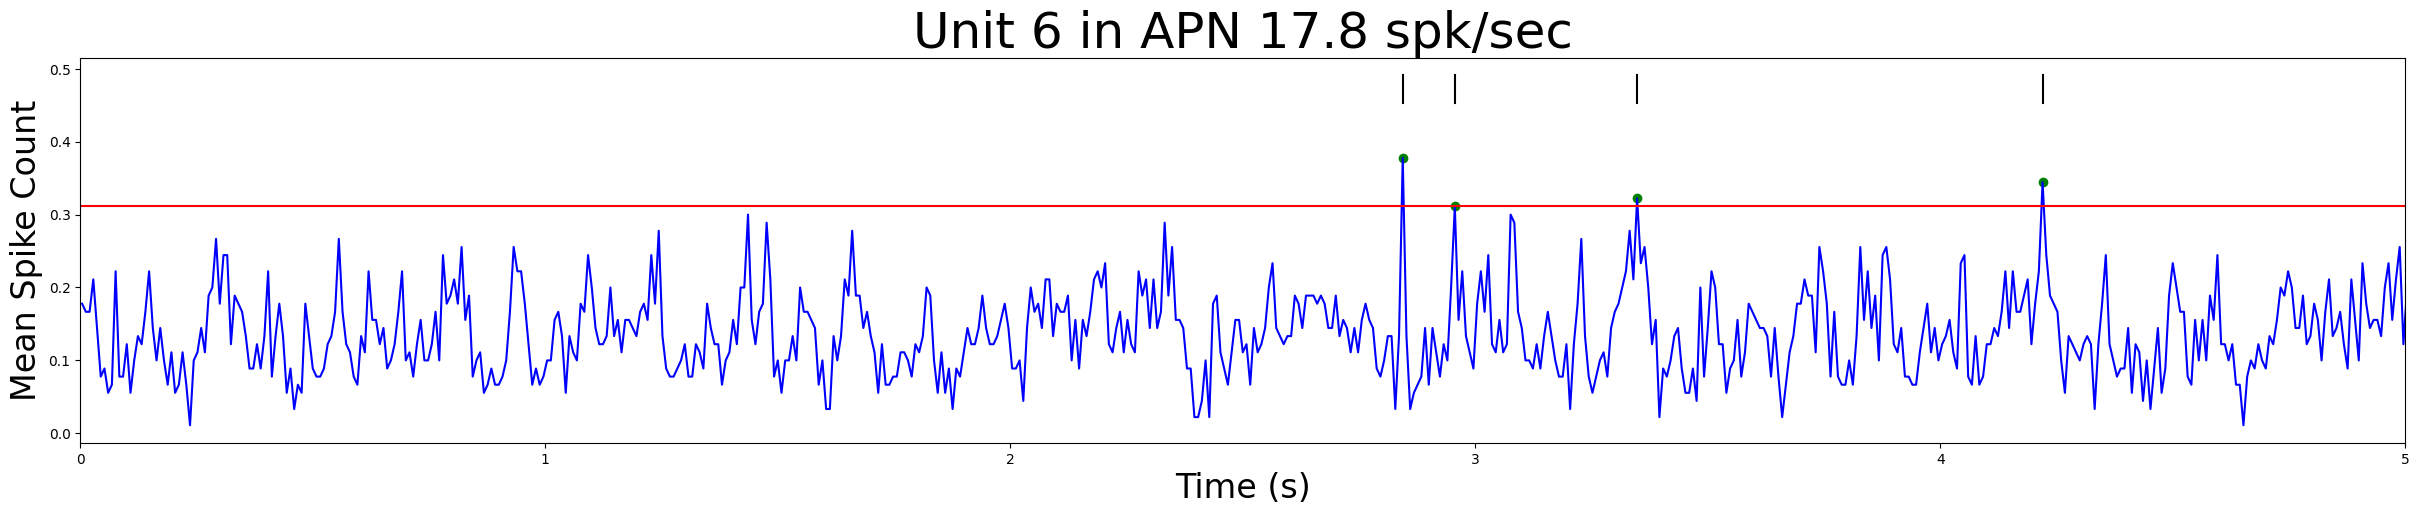

In [699]:
# Extract barcode for the example neuron and visualize it
bars, psth, t= find_bars(rasters[example], trial_duration, bin_duration, highThresh)
xlim=[0,5] # beginning and ending time to show in plot, in s
title = "Unit %d in %s %.1f spk/sec" % (example_indices[example], units_location[example_indices[example]],FR[example])
plotPSTHbarcode(psth, t, highThresh/nRepeats, bars,xlim,title)


In [700]:
# Compute the barcodes of all three example units
barcodes=[]
for i in range(len(example_indices)):
    rate=FR[example]*bin_duration # rate, expressed in spikes per time bin
    highThresh, lowThresh = getSpikeCountThreshold(rate, nRepeats, n_bins, alpha, False)
    bars, psth, t= find_bars(rasters[i], trial_duration, bin_duration, highThresh)
    barcodes.append(bars)
    print('Unit ',example_indices[i],' has ', len(bars), ' bars in its barcode')
    

Unit  0  has  0  bars in its barcode
Unit  1  has  134  bars in its barcode
Unit  2  has  0  bars in its barcode
Unit  3  has  0  bars in its barcode
Unit  4  has  0  bars in its barcode
Unit  5  has  0  bars in its barcode
Unit  6  has  4  bars in its barcode
Unit  7  has  1  bars in its barcode
Unit  8  has  0  bars in its barcode
Unit  9  has  0  bars in its barcode
Unit  10  has  257  bars in its barcode
Unit  11  has  0  bars in its barcode
Unit  13  has  37  bars in its barcode
Unit  15  has  0  bars in its barcode
Unit  16  has  0  bars in its barcode
Unit  17  has  0  bars in its barcode
Unit  18  has  0  bars in its barcode
Unit  19  has  0  bars in its barcode
Unit  20  has  0  bars in its barcode
Unit  21  has  71  bars in its barcode
Unit  22  has  0  bars in its barcode
Unit  23  has  0  bars in its barcode
Unit  24  has  0  bars in its barcode
Unit  25  has  0  bars in its barcode
Unit  28  has  0  bars in its barcode
Unit  29  has  0  bars in its barcode
Unit  30  has  0

In [701]:
print(bars)

[]


In [702]:
# spkd:  helper function implementing a simple algorithm to compute the minimum edit distance  
def spkd(tli, tlj, cost):
    '''
    Determines the minimum number of operations required to convert one bar code into the other 
    where the legal steps are to add a bar, delete a bar, or move a bar over by cost seconds
    INPUTS:
    tli        array of event times in one example, in seconds
    tlj        array of event times in another example, in seconds
    cost       number of seconds you can shift an event for the same cost as deleting or adding a spike
    
    OUTPUTS:
    d          the distance between i and j 
  
    Translated to Python by Siddharth Vyasabattu 2025 from Matlab code by Daniel Reich
    Translated to Matlab by Daniel Reich 1999 from FORTRAN code by Jonathan Victor
    (used with permission from JV)
    
    '''
    nspi = len(tli)
    nspj = len(tlj)

    if cost == 0:
        return abs(nspi - nspj)
    elif cost == float('inf'):
        return nspi + nspj

    # Initialize the cost matrix
    scr = np.zeros((nspi + 1, nspj + 1))

    # Margins with the cost of adding a spike
    scr[:, 0] = np.arange(nspi + 1)
    scr[0, :] = np.arange(nspj + 1)

    # Calculate the costs for aligning spike trains
    if nspi > 0 and nspj > 0:
        for i in range(1, nspi + 1):
            for j in range(1, nspj + 1):
                scr[i, j] = min(
                    scr[i - 1, j] + 1,
                    scr[i, j - 1] + 1,
                    scr[i - 1, j - 1] + cost * abs(tli[i - 1] - tlj[j - 1])
                )
    d = scr[nspi, nspj]  #the distance metric
    return d

In [703]:
Barcode_A = [2, 3, 7]     #times of the bars, in s
Barcode_B =[2.1, 5, 7.2]  
Barcode_A, Barcode_B

([2, 3, 7], [2.1, 5, 7.2])

In [704]:
cost = 1 # cost per 1s shift in a spike time
#spkd(Barcode_A, Barcode_B, cost)

for i in range(len(barcodes) - 1):
    barcode_dist = spkd(barcodes[i], barcodes[i + 1], cost)

print(barcode_dist)

0.0


In [705]:
# recall the bar code lengths
for i in range(len(barcodes) - 1):
    print('Unit ',example_indices[i],' has ', len(barcodes[i]), ' bars in its barcode')
    
print('Worst case, deleting all the bars of the first and inserting all the bars of the second')
print('would cost ',len(barcodes[0]),' + ',len(barcodes[1]),' = ',len(barcodes[0])+len(barcodes[1]))

# choose a cost parameter
cost=125
# two spikes will be aligned if it is "cheaper" than deleting one and inserting the other
print('cost = ',cost,' means bars will be matched if they are <',2000/cost,' ms apart')

# The distance between the full length barcodes
d=spkd(barcodes[0],barcodes[1], cost)
print('For a cost of ',cost,' the distance is = ',np.round(d,1))

Unit  0  has  0  bars in its barcode
Unit  1  has  134  bars in its barcode
Unit  2  has  0  bars in its barcode
Unit  3  has  0  bars in its barcode
Unit  4  has  0  bars in its barcode
Unit  5  has  0  bars in its barcode
Unit  6  has  4  bars in its barcode
Unit  7  has  1  bars in its barcode
Unit  8  has  0  bars in its barcode
Unit  9  has  0  bars in its barcode
Unit  10  has  257  bars in its barcode
Unit  11  has  0  bars in its barcode
Unit  13  has  37  bars in its barcode
Unit  15  has  0  bars in its barcode
Unit  16  has  0  bars in its barcode
Unit  17  has  0  bars in its barcode
Unit  18  has  0  bars in its barcode
Unit  19  has  0  bars in its barcode
Unit  20  has  0  bars in its barcode
Unit  21  has  71  bars in its barcode
Unit  22  has  0  bars in its barcode
Unit  23  has  0  bars in its barcode
Unit  24  has  0  bars in its barcode
Unit  25  has  0  bars in its barcode
Unit  28  has  0  bars in its barcode
Unit  29  has  0  bars in its barcode
Unit  30  has  0

In [706]:
# To illustrate suppose a barcode had bars at 2, 4 and 7s
examplebarcode=bars
print('example bar code = ',examplebarcode)

# and suppose the random offset was 1.5s
offset = 1.5
print('offset = ', offset)

# this adds the offset to each bar's time
for i in range(len(examplebarcode)):
    examplebarcode[i] += offset
print('shifted bar code = ',examplebarcode)
print('stimulus duration = ',trial_duration)

# this wraps the values exceeding the trial duration back to 
# the beginning and sorts them in order again
permutedexample = np.sort( examplebarcode % trial_duration )
print('permuted bar code = ',permutedexample)

example bar code =  []
offset =  1.5
shifted bar code =  []
stimulus duration =  8.007
permuted bar code =  []


In [707]:
# permute_barcode: helper function to permute barcodes
def permute_barcode(barcode,trial_duration):
    random_offset = np.random.uniform(0, trial_duration)
    for i in range(len(barcode)):
        barcode[i] += random_offset
    permutedcode = np.sort(barcode % trial_duration)
    return permutedcode

In [708]:
permuted_barcode1 = permute_barcode(barcodes[0], trial_duration)
control_d = spkd(permuted_barcode1, barcodes[1], cost)
print('For a shift cost of ',cost)
print('The distance from permuted neuron1 to neuron2 was ',np.round(control_d,1))

For a shift cost of  125
The distance from permuted neuron1 to neuron2 was  134.0


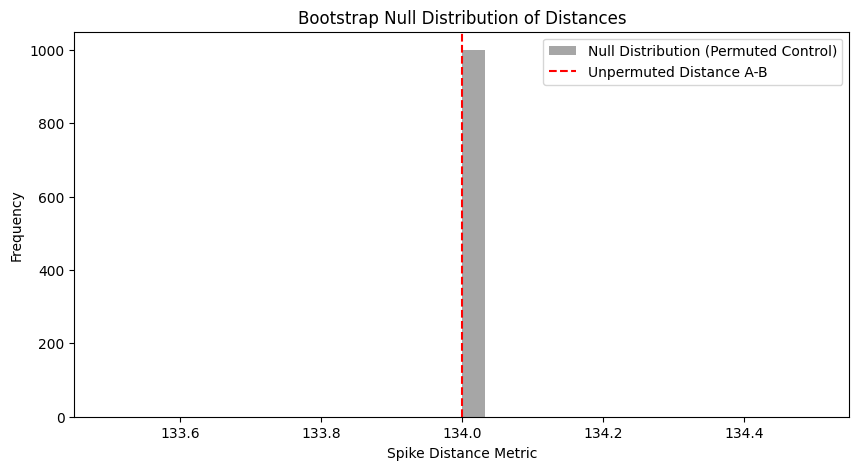

In [709]:
perm_barcode_dist = []
for i in range(1000):
    permuted_barcode1 =  permute_barcode(barcodes[0], trial_duration)
    perm_barcode_dist.append(spkd(permuted_barcode1, barcodes[1], cost))
plt.figure(figsize=(10, 5))
plt.hist(perm_barcode_dist, bins=30, color='gray', alpha=0.7, label="Null Distribution (Permuted Control)")
plt.axvline(x=d, color='red', linestyle='--', label="Unpermuted Distance A-B")
plt.xlabel("Spike Distance Metric")
plt.ylabel("Frequency")
plt.title("Bootstrap Null Distribution of Distances")
plt.legend()
plt.show()

In [710]:
# extract epoch times from stim table where stimulus rows have a different 'block' than following row
# returns list of epochs, where an epoch is of the form (stimulus name, stimulus block, start time, stop time)
def extract_epochs(stim_name, stim_table, epochs):
    
    # specify a current epoch stop and start time
    epoch_start = stim_table.start_time[0]
    epoch_stop = stim_table.stop_time[0]

    # for each row, try to extend current epoch stop_time
    for i in range(len(stim_table)):
        this_block = stim_table.stimulus_block[i]
        # if end of table, end the current epoch
        if i+1 >= len(stim_table):
            epochs.append((stim_name, this_block, epoch_start, epoch_stop))
            break
            
        next_block = stim_table.stimulus_block[i+1]
        # if next row is the same stim block, push back epoch_stop time
        if next_block == this_block:
            epoch_stop = stim_table.stop_time[i+1]
        # otherwise, end the current epoch, start new epoch
        else:
            epochs.append((stim_name, this_block, epoch_start, epoch_stop))
            epoch_start = stim_table.start_time[i+1]
            epoch_stop = stim_table.stop_time[i+1]
    
    return epochs

In [711]:
# extract epochs from all valid stimulus tables
epochs = []
for stim_name in nwb.intervals.keys():
    stim_table = nwb.intervals[stim_name]
    try:
        epochs = extract_epochs(stim_name, stim_table, epochs)
    except:
        continue

# manually add optotagging epoch since the table is stored separately
opto_stim_table = nwb.processing["optotagging"]["optogenetic_stimulation"]
opto_epoch = ("optogenetic_stimulation", 1.0, opto_stim_table.start_time[0], opto_stim_table.stop_time[-1])
epochs.append(opto_epoch)

# epochs take the form (stimulus name, stimulus block, start time, stop time)
print(len(epochs))
epochs.sort(key=lambda x: x[2])
for epoch in epochs:
    print(epoch)

6
('UniqueFFF_presentations', np.float64(0.0), np.float64(43.36058), np.float64(163.46116))
('RepeatFFF_presentations', np.float64(1.0), np.float64(163.46116), np.float64(884.0658))
('UniqueFFF_presentations', np.float64(2.0), np.float64(884.0658), np.float64(1004.16662))
('static_block_presentations', np.float64(3.0), np.float64(1004.16662), np.float64(6769.02092))
('receptive_field_block_presentations', np.float64(4.0), np.float64(6769.02092), np.float64(7249.424086666666))
('optogenetic_stimulation', 1.0, np.float64(7265.1189), np.float64(8134.21212))


In [712]:
time_start = floor(min([epoch[2] for epoch in epochs]))
time_end = ceil(max([epoch[3] for epoch in epochs]))
all_units_spike_times = np.concatenate(units_spike_times).ravel()
print(time_start, time_end)

# make histogram of unit spikes per second over specified timeframe
time_bin_edges = np.linspace(time_start, time_end, (time_end-time_start))
hist, bins = np.histogram(all_units_spike_times, bins=time_bin_edges)

43 8135


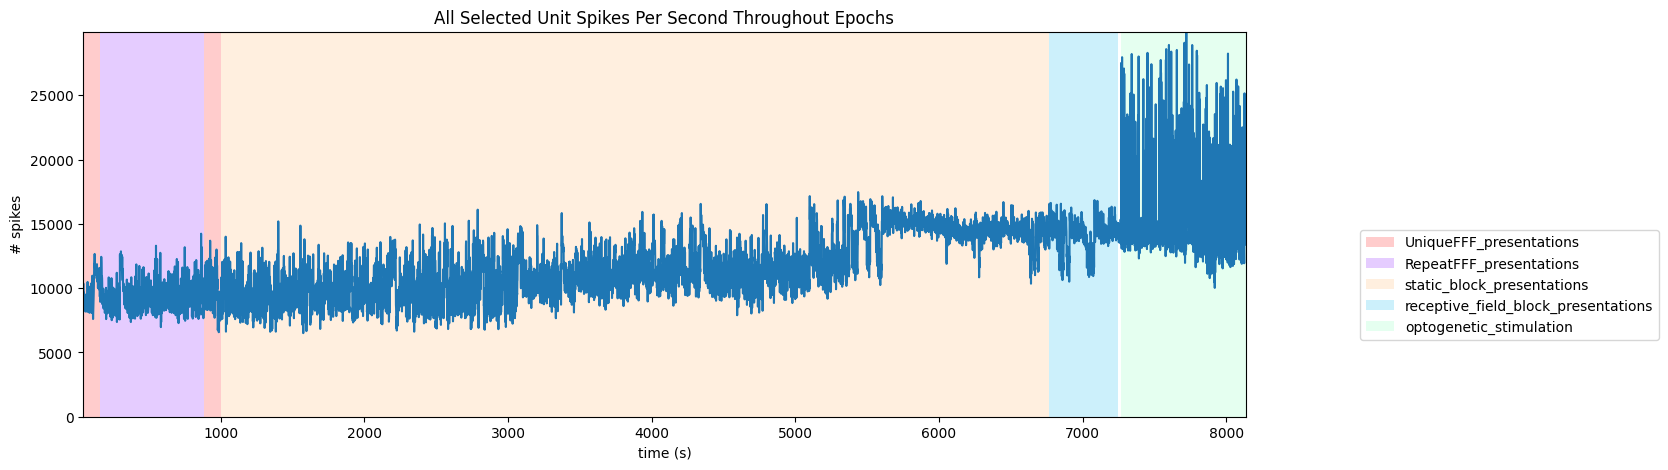

In [713]:
# generate plot of spike histogram with colored epoch intervals and legend
fig, ax = plt.subplots(figsize=(15,5))

# assign unique color to each stimulus name
stim_names = list({epoch[0] for epoch in epochs})
colors = plt.cm.rainbow(np.linspace(0,1,len(stim_names)))
stim_color_map = {stim_names[i]:colors[i] for i in range(len(stim_names))}

epoch_key = {}
height = max(hist)
# draw colored rectangles for each epoch
for epoch in epochs:
    stim_name, stim_block, epoch_start, epoch_end = epoch
    color = stim_color_map[stim_name]
    rec = ax.add_patch(mpl.patches.Rectangle((epoch_start, 0), epoch_end-epoch_start, height, alpha=0.2, facecolor=color))
    epoch_key[stim_name] = rec

ax.set_xlim(time_start, time_end)
ax.set_ylim(-0.1, height+0.1)
ax.set_xlabel("time (s)")
ax.set_ylabel("# spikes")
ax.set_title("All Selected Unit Spikes Per Second Throughout Epochs")

fig.legend(epoch_key.values(), epoch_key.keys(), loc="lower right", bbox_to_anchor=(1.18, 0.25))
ax.plot(bins[:-1], hist)

In [714]:
# make a list with indexes of units mapped to an area 
areasToInclude=['SCsg'] #  ['SCig', 'SCiw', 'SCop', 'SCsg']
RFunits=[]
for i in range(len(units_quality)):
    if units_location[i] in areasToInclude and units_quality[i] == "good":
        RFunits.append(i)
        
print('Found ', len(RFunits), 'units mapped to ', areasToInclude)

Found  0 units mapped to  ['SCsg']


In [715]:
### get receptive field of a unit using its spike times and the stim table
rf_stim_table = nwb.intervals["receptive_field_block_presentations"]
### get x and y coordinates of gabors displayed to build receptive field

xs = np.sort(list(set(rf_stim_table.x_position)))
ys = np.sort(list(set(rf_stim_table.y_position)))
field_units = rf_stim_table.units[0]

In [716]:
# helper function to extract one unit's firing rate as a function of gabor location
def get_rf(spike_times,rf_stim_table):
    # INPUT
    #  spike_times: the spike times of one unit
    #
    onset_delay = 0.2
    # creates 2D array that stores response spike counts for each coordinate of the receptive field
    unit_rf = np.zeros([ys.size, xs.size])
    # for every x and y coordinate in the field
    for xi, x in enumerate(xs):
        for yi, y in enumerate(ys):
            
            # for this coordinate of the rf, count all the times that this neuron responds to a stimulus time with a spike
            # stim_times = rf_stim_table[(rf_stim_table.x_position == x) & (rf_stim_table.y_position == y)].start_time
            response_spike_count = 0
            for i in range(len(rf_stim_table)):
                if rf_stim_table['x_position'][i] != x or rf_stim_table['y_position'][i] != y:
                    continue
                start, end = rf_stim_table['start_time'][i], rf_stim_table['stop_time'][i]
                # any spike within 0.2 seconds after stim time is considered a response
                start_idx, end_idx = np.searchsorted(spike_times, [start+onset_delay, end+onset_delay])
                response_spike_count += end_idx-start_idx

            unit_rf[yi, xi] = response_spike_count
    
    return unit_rf

In [717]:
# compute receptive fields of selected units (this can take some time)
rfs = []
for unit_idx in RFunits: 
    unit_spike_times = nwb.units['spike_times'][unit_idx]
    rfs.append(get_rf(unit_spike_times,rf_stim_table))

In [718]:
### helper function to display the receptive fields for each unit in a 2D plot

def display_rfs(unit_rfs):
    n_cols = 10
    n_rows = len(unit_rfs)//n_cols
    fig, axes = plt.subplots(n_rows+1, n_cols)
    fig.set_size_inches(12, n_rows+1)

    # handle case where there's <= 10 rfs
    if len(axes.shape) == 1:
        axes = axes.reshape((1, axes.shape[0]))

    for irf, rf in enumerate(unit_rfs):
        ax_row = int(irf/10)
        ax_col = irf%10
        axes[ax_row][ax_col].imshow(rf, origin="lower")
    for ax in axes.flat[1:]:
        ax.axis('off')

    # making axis labels for first receptive field
    axes[0][0].set_xlabel(field_units)
    axes[0][0].set_ylabel(field_units)
    axes[0][0].xaxis.set_label_position("top") 
    axes[0][0].xaxis.set_ticks_position("top")
    axes[0][0].set_xticks(range(len(xs)), xs, rotation=90, fontsize=6)
    axes[0][0].set_yticks(range(len(ys)), ys, fontsize=6)

    for i, l in enumerate(axes[0][0].xaxis.get_ticklabels()):
        if i % 2 != 0:
            l.set_visible(False)
    for i, l in enumerate(axes[0][0].yaxis.get_ticklabels()):
        if i % 2 != 0:
            l.set_visible(False)

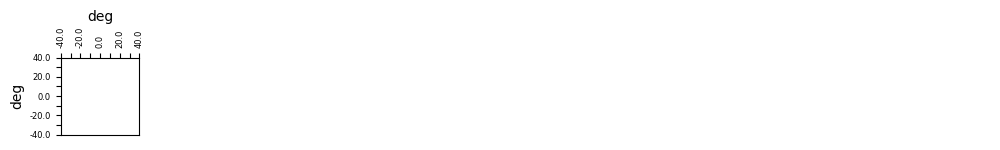

In [719]:
# display the receptive fields 
display_rfs(rfs)